<a href="https://colab.research.google.com/github/jmgoff/FitSNAP-1/blob/update_tutorials/tutorial_ace_inp_and_lammps_md.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Multi-element ACE and LAMMPS MD workflow example

This notebook walks through two connected steps: first a compact InP multi-element ACE training example, then a Ta-to-LAMMPS MD example using a fitted potential.
The MD example is pedagogical. In this notebook we keep runs short; in non-interactive scripts, you can extend them for longer production-style checks.


Student start:
1) read the local/Colab note and version checks,
2) run the optional `default_ACE_settings.py` snippet for your element set,
3) run the InP fit cell before the LAMMPS MD cell so the data path exists.


In [26]:
import os
import sys
import shutil
import subprocess
from pathlib import Path

ON_COLAB = "google.colab" in sys.modules

if ON_COLAB:
    # Explicit Colab bootstrap: install dependencies, build LAMMPS with ACE/PACE,
    # and install FitSNAP in editable mode for the tutorial workflow.
    subprocess.run("apt-get update", shell=True, check=True)
    subprocess.run(
        "apt-get install -y cmake build-essential git ccache openmpi-bin "
        "libopenmpi-dev python3-dev python3-venv",
        shell=True,
        check=True,
    )
    subprocess.run(
        f"{sys.executable} -m pip install --upgrade pip wheel setuptools",
        shell=True,
        check=True,
    )
    subprocess.run(
        f"{sys.executable} -m pip install numpy scipy scikit-learn virtualenv "
        "psutil pandas tabulate mpi4py Cython sympy pyyaml ase matplotlib",
        shell=True,
        check=True,
    )
    os.chdir("/content")
    if not Path("FitSNAP").exists():
        subprocess.run("git clone https://github.com/FitSNAP/FitSNAP.git", shell=True, check=True)
    if not Path("lammps").exists():
        subprocess.run("git clone https://github.com/lammps/lammps.git", shell=True, check=True)
    # Check out the stable tag used by this tutorial stack.
    os.chdir("/content/lammps")
    subprocess.run("git checkout stable_22Jul2025_update4", shell=True, check=True)
    build = Path("build-fitsnap-ace")
    build.mkdir(exist_ok=True)
    os.chdir(build)
    # Shared library + ML packages keep the Python interface and ACE path available.
    cmake_cmd = [
        "cmake", "../cmake",
        "-DLAMMPS_EXCEPTIONS=yes",
        "-DBUILD_SHARED_LIBS=yes",
        "-DMLIAP_ENABLE_PYTHON=yes",
        "-DMLIAP_ENABLE_ACE=yes",
        "-DPKG_PYTHON=yes",
        "-DPKG_ML-SNAP=yes",
        "-DPKG_ML-IAP=yes",
        "-DPKG_ML-PACE=yes",
        "-DPKG_SPIN=yes",
        f"-DPYTHON_EXECUTABLE:FILEPATH={sys.executable}",
    ]
    subprocess.run(cmake_cmd, check=True)
    subprocess.run(["cmake", "--build", ".", "-j2"], check=True)
    try:
        # The 'install-python' target fails due to venv issues; install directly with pip.
        # The LAMMPS Python module source is typically in the 'python' directory relative to the LAMMPS root.
        lammps_python_source_dir = Path("/content/lammps/python")
        if not lammps_python_source_dir.exists():
            raise FileNotFoundError(f"LAMMPS Python module source directory not found at {lammps_python_source_dir}.")

        print(f"Attempting to install LAMMPS Python module from: {lammps_python_source_dir}")
        subprocess.run(
            f"{sys.executable} -m pip install {lammps_python_source_dir}",
            shell=True,
            check=True,
        )
    except subprocess.CalledProcessError as e:
        print(f"Error during 'pip install' of LAMMPS Python module:")
        print(f"Return code: {e.returncode}")
        print(f"stdout: {e.stdout.decode()}")
        print(f"stderr: {e.stderr.decode()}")
        raise # Re-raise the exception after printing details

    # --- Start of robust environment variable setup ---
    lammps_build_dir = Path("/content/lammps/build-fitsnap-ace")
    lammps_symlink_path = lammps_build_dir / "liblammps.so"
    lammps_lib_real_path = None

    if lammps_symlink_path.exists() and lammps_symlink_path.is_symlink():
        resolved_path = os.readlink(lammps_symlink_path)
        if not Path(resolved_path).is_absolute():
            lammps_lib_real_path = lammps_build_dir / resolved_path
        else:
            lammps_lib_real_path = Path(resolved_path)
    elif (lammps_build_dir / "liblammps.so.0").exists():
        lammps_lib_real_path = lammps_build_dir / "liblammps.so.0"
    elif lammps_symlink_path.exists():
         lammps_lib_real_path = lammps_symlink_path

    if lammps_lib_real_path and lammps_lib_real_path.exists():
        os.environ["LAMMPS_PYTHON_LIB"] = str(lammps_lib_real_path)
        print(f"LAMMPS_PYTHON_LIB set to: {os.environ['LAMMPS_PYTHON_LIB']}")

        target_symlink_dir = Path("/usr/local/lib")
        target_symlink_dir.mkdir(parents=True, exist_ok=True)
        target_symlink_name = "liblammps.so"
        target_symlink_path = target_symlink_dir / target_symlink_name

        # Always try to remove and create the symlink to be explicit
        if target_symlink_path.exists():
            if target_symlink_path.is_symlink():
                target_symlink_path.unlink() # Remove existing symlink
                print(f"Removed old symlink: {target_symlink_path}")
            else:
                print(f"Warning: {target_symlink_path} exists and is not a symlink. Skipping deletion.")

        try:
            subprocess.run(["sudo", "ln", "-s", str(lammps_lib_real_path), str(target_symlink_path)], check=True)
            print(f"Created symlink: {target_symlink_path} -> {lammps_lib_real_path}")
            subprocess.run(["sudo", "ldconfig"], check=True)
            print("Ran sudo ldconfig to update linker cache.")
        except subprocess.CalledProcessError as e:
            print(f"Error creating symlink or running ldconfig for {target_symlink_path}: {e}")
            raise # Re-raise to halt execution if this critical step fails

    else:
        print(f"Warning: Could not find resolved liblammps.so path. LAMMPS_PYTHON_LIB not set.")
        print(f"Searched: {lammps_symlink_path} and {lammps_build_dir / 'liblammps.so.0'}")
        raise FileNotFoundError("Critical LAMMPS shared library not found, cannot proceed.") # Halt execution if the library is not found

    # Explicitly set LD_LIBRARY_PATH to ensure our paths are first
    # This overwrites the environment variable, ensuring our paths are definitely present and prioritized.
    # We include existing LD_LIBRARY_PATH to not lose other system paths (if any).
    existing_ld_path = os.environ.get("LD_LIBRARY_PATH", "")
    new_ld_path_parts = []
    # Only add if not already at the beginning to avoid redundant entries and ensure prioritization
    if not existing_ld_path.startswith(str(target_symlink_dir)) and str(target_symlink_dir) not in existing_ld_path.split(os.pathsep):
        new_ld_path_parts.append(str(target_symlink_dir))
    if not existing_ld_path.startswith(str(lammps_build_dir)) and str(lammps_build_dir) not in existing_ld_path.split(os.pathsep):
        new_ld_path_parts.append(str(lammps_build_dir))

    # If new parts are added, prepend them. Otherwise, existing_ld_path remains.
    if new_ld_path_parts:
        os.environ["LD_LIBRARY_PATH"] = f"{os.pathsep.join(new_ld_path_parts)}:{existing_ld_path}"
        print(f"LD_LIBRARY_PATH explicitly set to: {os.environ['LD_LIBRARY_PATH']}")
    else:
        print(f"LD_LIBRARY_PATH already contains {lammps_build_dir} and {target_symlink_dir} at high priority. Current: {existing_ld_path}")

    # --- End of robust environment variable setup ---

    os.chdir("/content/FitSNAP")
    subprocess.run(f"{sys.executable} -m pip install -e . --no-deps", shell=True, check=True)

# Default to the paths used by the WSL environment we prepared, but allow override
# through environment variables for portability.
FITSNAP_DIR = Path(os.environ.get("FITSNAP_DIR", "/content/FitSNAP" if ON_COLAB else "~/software/FitSNAP")).expanduser()
LAMMPS_DIR = Path(os.environ.get("LAMMPS_DIR", "/content/lammps" if ON_COLAB else "~/software/lammps")).expanduser()
WORK_ROOT = Path(os.environ.get("FITSNAP_TUTORIAL_WORK", Path.cwd() / "fitsnap_tutorial_work")).expanduser()
WORK_ROOT.mkdir(parents=True, exist_ok=True)

if not FITSNAP_DIR.exists():
    raise FileNotFoundError(f"FitSNAP checkout not found: {FITSNAP_DIR}")
if str(FITSNAP_DIR) not in sys.path:
    sys.path.insert(0, str(FITSNAP_DIR))

# Add a short marker to help students orient where execution-specific logic diverges.
print("Execution context -> ON_COLAB:", ON_COLAB)
print("Start here for local tutorial workflow; ON_COLAB blocks are only needed in Colab runtimes.")
print(f"ON_COLAB = {ON_COLAB}")
print(f"FITSNAP_DIR = {FITSNAP_DIR}")
print(f"LAMMPS_DIR = {LAMMPS_DIR}")
print(f"WORK_ROOT = {WORK_ROOT}")

Attempting to install LAMMPS Python module from: /content/lammps/python
LAMMPS_PYTHON_LIB set to: /content/lammps/build-fitsnap-ace/liblammps.so.0
Removed old symlink: /usr/local/lib/liblammps.so
Created symlink: /usr/local/lib/liblammps.so -> /content/lammps/build-fitsnap-ace/liblammps.so.0
Ran sudo ldconfig to update linker cache.
LD_LIBRARY_PATH already contains /content/lammps/build-fitsnap-ace and /usr/local/lib at high priority. Current: /usr/local/lib/python3.12/dist-packages/cv2/../../lib64:/usr/local/lib:/content/lammps/build-fitsnap-ace:
Execution context -> ON_COLAB: True
Start here for local tutorial workflow; ON_COLAB blocks are only needed in Colab runtimes.
ON_COLAB = True
FITSNAP_DIR = /content/FitSNAP
LAMMPS_DIR = /content/lammps
WORK_ROOT = /content/FitSNAP/fitsnap_tutorial_work


### Run this once and verify dependencies before launching the InP or MD ...
- Run this once and verify dependencies before launching the InP or MD sections.
- If path assumptions differ from your setup, set `FITSNAP_DIR` and `LAMMPS_DIR` once here.


In [ ]:
import importlib.metadata as metadata
import platform

def run_text(cmd, cwd=None):
    # Small helper to keep version checks robust in notebooks and terminals.
    try:
        result = subprocess.run(cmd, cwd=cwd, text=True, capture_output=True, check=False)
        text = (result.stdout or result.stderr).strip()
        return text.splitlines()[0] if text else f"exit status {result.returncode}"
    except Exception as exc:
        return f"unavailable: {type(exc).__name__}: {exc}"

def git_version(path):
    # Track exact upstream revision for future reproducibility.
    if not Path(path, ".git").exists():
        return "not a git checkout"
    desc = run_text(["git", "describe", "--tags", "--always", "--dirty"], cwd=path)
    sha = run_text(["git", "rev-parse", "--short", "HEAD"], cwd=path)
    return f"{desc} ({sha})"

print("Python:", sys.version.replace("\n", " "))
print("Platform:", platform.platform())
print("Executable:", sys.executable)
print("CONDA_PREFIX:", os.environ.get("CONDA_PREFIX", "not set"))
print("FitSNAP git:", git_version(FITSNAP_DIR))
print("LAMMPS git:", git_version(LAMMPS_DIR))

for package in ["fitsnap3", "lammps", "numpy", "scipy", "scikit-learn", "pandas", "mpi4py", "ase", "sympy", "pyyaml", "matplotlib"]:
    try:
        print(f"{package}: {metadata.version(package)}")
    except metadata.PackageNotFoundError:
        print(f"{package}: not installed as a package")

try:
    import lammps
    lmp = lammps.lammps()
    print("LAMMPS Python version integer:", lmp.version())
    lmp.close()
except Exception as exc:
    print("LAMMPS Python check failed:", repr(exc))


Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Platform: Linux-6.6.122+-x86_64-with-glibc2.35
Executable: /usr/bin/python3
CONDA_PREFIX: not set
FitSNAP git: v3.1.0-209-g1a9b0507 (1a9b0507)
LAMMPS git: stable_22Jul2025_update4 (611ca3b7f8)
fitsnap3: 3.1.1.0
lammps: 2025.7.22
numpy: 2.0.2
scipy: 1.16.3
scikit-learn: 1.6.1
pandas: 2.2.2
mpi4py: 4.1.2
ase: 3.29.0
sympy: 1.14.0
pyyaml: 6.0.3
matplotlib: 3.10.0
LAMMPS Python version integer: 20250722


### Run this once at the notebook top to verify path and import assumptio...
- Run this once at the notebook top to verify path and import assumptions on your machine or Colab.
- If `FITSNAP_DIR`/`LAMMPS_DIR` are different, set them once and keep them constant.


In [ ]:
from copy import deepcopy

import numpy as np
import pandas as pd
from mpi4py import MPI
from fitsnap3lib.fitsnap import FitSnap

# Keep one communicator object and print rank info so students can run both 1-proc
# and multi-proc examples without changing the code.
comm = MPI.COMM_WORLD
rank = comm.Get_rank()
print(f"MPI rank {rank} of {comm.Get_size()}")


Generating your first pickled library of CG coefficients. This will take a few moments...
Generating your first pickled library of Wigner 3j coefficients. This will take a few moments...
MPI rank 0 of 1


### This section creates the communicator and common imports used by all ...
- This section creates the communicator and common imports used by all solver loops.
- Keep the `comm` object unchanged unless you are intentionally running true multi-rank MPI examples.


## Reproducible ACE starting values with `tools/default_ACE_settings.py`

`default_ACE_settings.py` is a helper script that estimates physically reasonable
`rcutfac` and `lambda` starting values from element radii.

For a classroom workflow:
1) start from a small input (single element: `Ta`),
2) then run for multi-element systems (`In` and `P`) when needed.
Small edits are often necessary, so we copy the script to your work folder and
edit the `elems` line there, instead of touching your installed package file.


### Classroom pattern for this helper script

We keep a local copy in the working directory so students can make small, visible
edits. We then run it and print the suggested starting hyperparameters in notebook
output.


In [ ]:
default_tool_src = FITSNAP_DIR / "tools" / "default_ACE_settings.py"
default_tool_local = WORK_ROOT / "default_ACE_settings.py"
helper_script = WORK_ROOT / "default_ACE_settings_run.py"

if not default_tool_src.exists():
    raise FileNotFoundError(f"default_ACE_settings.py not found: {default_tool_src}")

if not default_tool_local.exists():
    shutil.copy2(default_tool_src, default_tool_local)
print(f"default_ACE_settings.py copied/loaded at: {default_tool_local}")
print("Preview (first 40 lines):")
for line_num, line in enumerate(default_tool_local.read_text().splitlines()[:40], start=1):
    print(f"{line_num:3d}: {line}")


def run_default_ace_settings(elements, nshell=2.2, label=""):
    # Copy the tool into a temporary file, replace the element list,
    # then print its suggested hyperparameter lines. This keeps the original
    # repository script untouched and makes edits explicit for classroom notes.
    label = label or str(elements)
    text = default_tool_local.read_text()
    marker = "elems = ['N','W']"
    replacement = f"elems = {elements}"
    if marker not in text:
        raise RuntimeError(f"Expected marker '{marker}' in copied default_ACE_settings.py")
    text = text.replace(marker, replacement, 1)
    text = text.replace("nshell=2.2", f"nshell={nshell}", 1)
    helper_script.write_text(text)
    result = subprocess.run(
        [sys.executable, str(helper_script)],
        text=True,
        capture_output=True,
        check=False,
    )
    print(f"\nRunning default_ACE_settings for {label}")
    print("return code:", result.returncode)
    output = (result.stdout or result.stderr or "").strip()
    print(output if output else "No output produced.")


run_default_ace_settings("['Ta']", label="Ta")


default_ACE_settings.py copied/loaded at: /content/FitSNAP/fitsnap_tutorial_work/default_ACE_settings.py
Preview (first 40 lines):
  1: from ase.data import *
  2: import numpy as np
  3: import itertools
  4: 
  5: # Note: to use this script, you'll need to have the ASE package installed
  6: # for conda:  https://anaconda.org/conda-forge/ase
  7: # for pip:  https://pypi.org/project/ase/
  8: # SEE BOTTOM OF SCRIPT FOR EXAMPLE
  9: 
 10: 
 11: # ionic radii from mendeleev (ionic radii in crystals from slater 1964) in angstroms
 12: ionic_radii =  {'H': 0.25, 'He': 1.2, 'Li': 1.45, 'Be': 1.05, 'B': 0.85, 'C': 0.7, 'N': 0.65, 'O': 0.6, 'F': 0.5, 'Ne': 1.6, 'Na': 1.8, 'Mg': 1.5, 'Al': 1.25, 'Si': 1.1, 'P': 1.0, 'S': 1.0, 'Cl': 1.0, 'Ar': 0.71, 'K': 2.2, 'Ca': 1.8, 'Sc': 1.6, 'Ti': 1.4, 'V': 1.35, 'Cr': 1.4, 'Mn': 1.4, 'Fe': 1.4, 'Co': 1.35, 'Ni': 1.35, 'Cu': 1.35, 'Zn': 1.35, 'Ga': 1.3, 'Ge': 1.25, 'As': 1.15, 'Se': 1.15, 'Br': 1.15, 'Kr': np.nan, 'Rb': 2.35, 'Sr': 2.0, 'Y': 1.8, 'Zr': 

### Ta, keep nshell = 2.2 as a first pass and inspect how much rcutfac
- For Ta, keep `nshell = 2.2` as a first pass and inspect how much `rcutfac`
  and `lambda` change from the printed suggestion.
- If your element set is different, swap in `run_default_ace_settings("[...]", nshell=...)`
  with explicit element labels and rerun this same cell.
- To compare multiple projects, save the local helper as `default_ACE_settings_run.py`
  and change only `elems` and `nshell` line-by-line.


### A local run, keep fitsnap_dir and lammps_dir fixed until both the...
- For a local run, keep `FITSNAP_DIR` and `LAMMPS_DIR` fixed until both the InP and MD steps work.
- This section assumes the previous utilities are available; if `default_ACE_settings.py` fails,
  verify that `FITSNAP_DIR` is a complete checkout first.


## Suggested `default_ACE_settings.py` values for InP


In [ ]:
# InP is a two-element system, so we ask for a two-element starting suggestion.
run_default_ace_settings("['In', 'P']", label="In, P", nshell=1.3)



Running default_ACE_settings for In, P
return code: 0
{('In', 'In'): [3.1, np.float64(3.48)], ('In', 'P'): [2.55, np.float64(3.14)], ('P', 'In'): [2.55, np.float64(3.14)], ('P', 'P'): [2.0, np.float64(2.8)]}
['In', 'P']
Suggested starting point for reference:

pair_style = hybrid/overlay zero 8.052222 zbl 5.629556 6.433778 zbl 4.868111 5.563556 zbl 4.106667 4.693333
pair_coeff1 = * * zero
pair_coeff2 = 1 1 zbl 1    49 49
pair_coeff3 = 1 2 zbl 2    49 15
pair_coeff4 = 2 2 zbl 3    15 15


recommended starting hyperparameters

rcutfac = 8.042  6.954  6.954  5.867
lambda = 0.402  0.348  0.348  0.293
rcinner = 0.775  0.637  0.637  0.500
drcinner = 0.01  0.01  0.01  0.01


### Compare the suggested In/P values to the Ta values and use them only ...
- Compare the suggested In/P values to the Ta values and use them only as starting points.
- For binary systems, element order in `type = In P` is important for later `pair_coeff` and weight consistency.


## InP multi-element ACE input


### What is being read

`InP-example.in` has type declarations (`type = In P`), element-specific cutoff arrays,
and a training/testing split that is useful to reuse for your own binary systems.


In [ ]:
inp_source = FITSNAP_DIR / "examples" / "InP_PACE" / "InP-example.in"
print("\n".join(inp_source.read_text().splitlines()[:80]))


[ACE]
numTypes = 2
rcutfac = 5.790  5.007  5.007  4.224
lambda = 1.737  1.502  1.502  1.267
rcinner = 1.705  1.403  1.403  1.100
drcinner = 0.01 0.01 0.01 0.01
ranks = 1 2 3 4
lmax =  1 2 2 1
nmax =  22 3 2 1
mumax = 2
lmin = 0 0 1 1
erefs = 0 0
nmaxbase = 22
type = In P
bzeroflag = 1

[CALCULATOR]
calculator = LAMMPSPACE
energy = 1
force = 1
stress = 0

[ESHIFT]
In = -1.65967588701534
P = 4.38159549501534

[SOLVER]
solver = RIDGE
compute_testerrs = 1
detailed_errors = 1

[RIDGE]
alpha=1.E-5

[SCRAPER]
scraper = JSON

[PATH]
dataPath = ../InP_JPCA2020/JSON

[OUTFILE]
output_style = PACE
metrics = InP_metrics.md
potential = InP_pot

[REFERENCE]
units = metal
atom_style = atomic
pair_style = hybrid/overlay zero 5.8 
pair_coeff1 = * * zero

[GROUPS]
group_sections = name training_size testing_size eweight fweight vweight
group_types = str float float float float float
smartweights = 1
random_sampling = 0
aa       =     0.95      0.05      1.00000000      100.00000000      1.E-12
aIn      

### This file is the exact upstream layout. Keep file section order and o...
- This file is the exact upstream layout. Keep file section order and only swap the few
  training/validation weights and paths in the next notebook cell for fast classroom experiments.
- Confirm your binary dataset path matches the environment checkout before fitting.


## Reduced InP fit


### What is being changed

To keep this notebook quick, group weights are reduced from full-production defaults and file paths are made absolute. The ACE descriptor block is otherwise kept intact so students can see which edits are safe defaults vs. structural edits.


In [27]:
inp_work = WORK_ROOT / "inp_demo"
inp_work.mkdir(parents=True, exist_ok=True)
inp_input = inp_work / "InP-example-reduced.in"
text = inp_source.read_text()
# Keep the sample fast by using small group weights and explicit absolute paths.
text = text.replace("dataPath = ../InP_JPCA2020/JSON", f"dataPath = {FITSNAP_DIR / 'examples' / 'InP_JPCA2020' / 'JSON'}")
text = text.replace("metrics = InP_metrics.md", f"metrics = {inp_work / 'InP_metrics.md'}")
text = text.replace("potential = InP_pot", f"potential = {inp_work / 'InP_pot'}")
for group in ["aa", "aIn", "aP", "Bulk", "EOS", "iIn", "iP", "s_aa", "s_aIn", "s_aP", "Shear", "s_iIn", "s_iP", "Strain", "s_vIn", "s_vP", "s_vv", "vP"]:
    text = text.replace(f"{group}       =     0.95      0.05", f"{group}       =     0.10      0.02")
inp_input.write_text(text)

RUN_INP_FIT = True
if RUN_INP_FIT:
    original_cwd = Path.cwd()
    os.chdir(inp_work)
    try:
        # Use a local filename after chdir to avoid path translation edge cases.
        inp_snap = FitSnap(inp_input.name, comm=comm, arglist=["--overwrite"])
        inp_snap.scrape_configs()
        print("InP configurations on this rank:", len(inp_snap.data))
        inp_snap.process_configs()
        inp_snap.perform_fit()
        display(inp_snap.solver.errors)
    finally:
        os.chdir(original_cwd)
else:
    print("InP fit skipped. Set RUN_INP_FIT = True to run it.")



         Forcing testing size to add up properly.

'scrape_configs' took 259.98 ms on rank 0
InP configurations on this rank: 229
'process_configs' took 111078.51 ms on rank 0
'fit' took 502.73 ms on rank 0
'error_analysis' took 350.75 ms on rank 0


/content/FitSNAP/fitsnap3lib/solvers/solver.py:125: RuntimeWarning: divide by zero encountered in scalar divide
  rsq = 1 - ssr / np.sum(np.square(g['truths'] - (g['truths'] / nconfig).sum()))
/content/FitSNAP/fitsnap3lib/solvers/solver.py:132: RuntimeWarning: divide by zero encountered in scalar divide
  w_rsq = 1 - w_ssr / np.sum(np.square((g['weights'] * g['truths']) - (g['weights'] * g['truths'] / w_nconfig).sum()))


ncount       mae      rmse        rsq
Group Weighting  Testing  Subsystem                                       
*ALL  Unweighted Training Energy        189  0.008407  0.010963   0.999885
                          Force       34047  0.017597  0.029742   0.999148
                 Testing  Energy         40  0.015333  0.046011   0.997577
                          Force        8349  0.017989  0.035240   0.998469
      weighted   Training Energy        189  0.005452  0.007630   0.999992
...                                     ...       ...       ...        ...
vP    Unweighted Testing  Force         645  0.005467  0.009056 -11.493985
      weighted   Training Energy          1  0.011006  0.011006       -inf
                          Force         645  0.000868  0.001471  -3.001657
                 Testing  Energy          1  0.010997  0.010997       -inf
                          Force         645  0.000848  0.001404 -11.493985

[148 rows x 4 columns]

### If fitting is slow, reduce groups first or increase dataPath cutoff r...
- If fitting is slow, reduce groups first or increase `dataPath` cutoff rather than touching
  descriptor math first.
- Save the printed `inp_snap.solver.errors` as your benchmark before editing the next section.


## Train a Ta ACE potential for LAMMPS workflow example


### Why include Ta training here

This keeps the downstream MD section concrete: this is the same exported `.yace` pattern used in a production script, but with a reduced basis for quick completion.


In [ ]:
# Base Ta ACE input. Changing this one block (ACE + GROUPS) is usually enough to start
# experimentation for a different system.
ta_data = FITSNAP_DIR / "examples" / "Ta_Linear_JCP2014" / "JSON"
md_settings = {
    "ACE": {
        "numTypes": 1,
        "ranks": "1 2 3",
        "lmax": "0 2 2",
        "nmax": "8 3 1",
        "nmaxbase": 8,
        "rcutfac": 4.604694451,
        "lambda": 3.059235105,
        "type": "Ta",
        "lmin": "0 0 1",
        "bzeroflag": 0,
        "b_basis": "minsub",
    },
    "CALCULATOR": {
        "calculator": "LAMMPSPACE",
        "energy": 1,
        "force": 1,
        "stress": 0,
    },
    "ESHIFT": {"Ta": 0.0},
    **{'SOLVER': {'solver': 'RIDGE', 'compute_testerrs': 1, 'detailed_errors': 1}, 'RIDGE': {'local_solver': 1, 'alpha': 1e-05}},
    "SCRAPER": {"scraper": "JSON"},
    "PATH": {"dataPath": str(ta_data)},
    "OUTFILE": {
        "output_style": "PACE",
        "metrics": str(WORK_ROOT / "Ta_md_demo_metrics.md"),
        "potential": str(WORK_ROOT / "Ta_md_demo_pot"),
    },
    "REFERENCE": {
        "units": "metal",
        "atom_style": "atomic",
        "pair_style": "hybrid/overlay zero 5.0 zbl 4.0 4.8",
        "pair_coeff1": "* * zero",
        "pair_coeff2": "* * zbl 73 73",
    },
    "GROUPS": {'group_sections': 'name training_size testing_size eweight fweight vweight', 'group_types': 'str float float float float float', 'smartweights': 0, 'random_sampling': 0, 'Displaced_A15': '0.20 0.05 1.0 10.0 1.0e-8', 'Displaced_BCC': '0.20 0.05 1.0 10.0 1.0e-8', 'Displaced_FCC': '0.20 0.05 1.0 10.0 1.0e-8', 'Elastic_BCC': '0.20 0.05 1.0 10.0 1.0e-8', 'Elastic_FCC': '0.20 0.05 1.0 10.0 1.0e-8', 'GSF_110': '0.20 0.05 1.0 10.0 1.0e-8', 'GSF_112': '0.20 0.05 1.0 10.0 1.0e-8', 'Liquid': '0.20 0.05 1.0 10.0 1.0e-8', 'Surface': '0.20 0.05 1.0 10.0 1.0e-8', 'Volume_A15': '0.20 0.05 1.0 10.0 1.0e-8', 'Volume_BCC': '0.20 0.05 1.0 10.0 1.0e-8', 'Volume_FCC': '0.20 0.05 1.0 10.0 1.0e-8'},
    "EXTRAS": {
        "dump_descriptors": 0,
        "dump_truth": 0,
        "dump_weights": 0,
    },
    "MEMORY": {"override": 0},
}
print("Data path:", md_settings["PATH"]["dataPath"])
print("Potential output prefix:", md_settings["OUTFILE"]["potential"])


Data path: /content/FitSNAP/examples/Ta_Linear_JCP2014/JSON
Potential output prefix: /content/FitSNAP/fitsnap_tutorial_work/Ta_md_demo_pot


### This is the Ta workflow block the MD section depends on; keep it work...
- This is the Ta workflow block the MD section depends on; keep it working before changing InP settings.
- You can switch `RIDGE` settings here, or set `local_solver` to a different solver for comparison runs.


In [ ]:
# This uses the same fit pipeline as the starter notebook.
md_snap = FitSnap(md_settings, comm=comm, arglist=["--overwrite"])
md_snap.scrape_configs()
md_snap.process_configs()
md_snap.perform_fit()
md_snap.output.write_lammps(md_snap.solver.fit)
md_snap.output.write_errors(md_snap.solver.errors)

yace_path = Path(md_settings["OUTFILE"]["potential"] + ".yace")
print("Wrote:", yace_path, "exists:", yace_path.exists())
display(md_snap.solver.errors)


'scrape_configs' took 163.86 ms on rank 0
'process_configs' took 2378.82 ms on rank 0
'fit' took 5.94 ms on rank 0
'error_analysis' took 137.56 ms on rank 0
Wrote: /content/FitSNAP/fitsnap_tutorial_work/Ta_md_demo_pot.yace exists: True


/content/FitSNAP/fitsnap3lib/solvers/solver.py:125: RuntimeWarning: divide by zero encountered in scalar divide
  rsq = 1 - ssr / np.sum(np.square(g['truths'] - (g['truths'] / nconfig).sum()))
/content/FitSNAP/fitsnap3lib/solvers/solver.py:132: RuntimeWarning: divide by zero encountered in scalar divide
  w_rsq = 1 - w_ssr / np.sum(np.square((g['weights'] * g['truths']) - (g['weights'] * g['truths'] / w_nconfig).sum()))


ncount           mae          rmse  \
Group      Weighting  Testing  Subsystem                                       
*ALL       Unweighted Training Energy         72  2.162074e-01  5.243468e-01   
                               Force        2664  8.698772e-02  1.475392e-01   
                      Testing  Energy         22  1.583537e-01  3.367976e-01   
                               Force        1272  1.259660e-01  1.987591e-01   
           weighted   Training Energy         72  2.162074e-01  5.243468e-01   
...                                          ...           ...           ...   
Volume_FCC Unweighted Testing  Force          24  1.236967e-13  2.024794e-13   
           weighted   Training Energy          6  7.327398e-01  1.008153e+00   
                               Force          72  4.386853e-13  1.262207e-12   
                      Testing  Energy          2  8.981226e-01  1.033404e+00   
                               Force          24  1.236967e-12  2.024794e-12   

                                                   rsq  
Group      Weighting  Testing  Subsystem                
*ALL       Unweighted Training Energy         0.979817  
                               Force          0.989035  
                      Testing  Energy         0.995485  
                               Force          0.985031  
           weighted   Training Energy         0.979817  
...                                                ...  
Volume_FCC Unweighted Testing  Force      -4439.402467  
           weighted   Training Energy         0.977758  
                               Force     -11494.390218  
                      Testing  Energy         0.995108  
                               Force      -4439.402467  

[104 rows x 4 columns]

### Reuse the same settings template for any single-element ACE training ...
- Reuse the same settings template for any single-element ACE training notebook.
- Keep this cell runnable even if you skip InP fitting; it creates the `.yace` file needed by the MD step.


## Run a Ta ACE MD example in LAMMPS


### Educational MD workflow

In a notebook we run 100 steps to keep the workflow quick in class.

For the longer 10,000-step check in the same potential, we run a separate local script at
the end of this section (not inside the classroom notebook cell) so students can keep the
teaching path short while still verifying longer-time stability on their own machine.


In [45]:
lmp_exe = LAMMPS_DIR / "build-fs-lammps" / "lmp"
if ON_COLAB:
    lmp_exe = LAMMPS_DIR / "build-fitsnap-ace" / "lmp"
if not lmp_exe.exists():
    raise FileNotFoundError(f"LAMMPS executable not found: {lmp_exe}")

md_run_dir = WORK_ROOT / "md_workflow"
md_run_dir.mkdir(parents=True, exist_ok=True)
nsteps = 100
# Keep this short in notebook form so students can complete the full workflow.

# Get the absolute path to the .yace file
abs_yace_path = WORK_ROOT / (Path(md_settings['OUTFILE']['potential']).name + ".yace")

# Get the path to the .mod file
mod_file_path = WORK_ROOT / (Path(md_settings['OUTFILE']['potential']).name + ".mod")

# Read the .mod file content and replace the relative path with the absolute path
if mod_file_path.exists():
    mod_content = mod_file_path.read_text()
    # Replace 'Ta_md_demo_pot.yace' with the absolute path to the .yace file
    # The actual filename is 'Ta_md_demo_pot.yace'
    original_yace_filename = Path(md_settings['OUTFILE']['potential']).name + ".yace"
    mod_content_corrected = mod_content.replace(original_yace_filename, str(abs_yace_path))
    mod_file_path.write_text(mod_content_corrected)
    print(f"Corrected .mod file: {mod_file_path}\nNew pair_coeff line for PACE: pair_coeff * * pace {abs_yace_path} Ta")
else:
    raise FileNotFoundError(f"Expected .mod file not found: {mod_file_path}")

# Build a minimal LAMMPS input for a short MD trajectory.
in_lines = [
    "variable nrep equal 2",
    "units metal",
    "boundary p p p",
    "lattice bcc 3.316",
    "region box block 0 2 0 2 0 2",
    "create_box 1 box",
    "create_atoms 1 box",
    "mass 1 180.88",
    f"include {mod_file_path}", # Include the generated potential.mod file
    "compute eatom all pe/atom",
    "compute energy all reduce sum c_eatom",
    "thermo_style custom step temp epair c_energy etotal press",
    "thermo 5",
    "thermo_modify norm yes",
    "timestep 0.5e-3",
    "neighbor 1.0 bin",
    "neigh_modify once no every 1 delay 0 check yes",
    "velocity all create 300.0 4928459 loop geom",
    "fix 1 all nvt temp 300.0 300.0 0.1",
    "log screen", # Add log screen for stdout capture
    f"run {nsteps}",
]
in_run = md_run_dir / "in.run"
in_run.write_text("\n".join(in_lines) + "\n")

print("Running LAMMPS input:", in_run)
result = subprocess.run([str(lmp_exe), "-in", str(in_run)], cwd=md_run_dir, text=True, capture_output=True, check=False)
print("\n--- LAMMPS STDOUT ---\n", result.stdout)
if result.stderr:
    print("\n--- LAMMPS STDERR ---\n", result.stderr)
if result.returncode != 0:
    raise RuntimeError(f"LAMMPS MD example failed with exit status {result.returncode}")

Corrected .mod file: /content/FitSNAP/fitsnap_tutorial_work/Ta_md_demo_pot.mod
New pair_coeff line for PACE: pair_coeff * * pace /content/FitSNAP/fitsnap_tutorial_work/Ta_md_demo_pot.yace Ta
Running LAMMPS input: /content/FitSNAP/fitsnap_tutorial_work/md_workflow/in.run

--- LAMMPS STDOUT ---
 LAMMPS (22 Jul 2025 - Update 4)
OMP_NUM_THREADS environment is not set. Defaulting to 1 thread.
  using 1 OpenMP thread(s) per MPI task
Lattice spacing in x,y,z = 3.316 3.316 3.316
Created orthogonal box = (0 0 0) to (6.632 6.632 6.632)
  1 by 1 by 1 MPI processor grid
Created 16 atoms
  using lattice units in orthogonal box = (0 0 0) to (6.632 6.632 6.632)
  create_atoms CPU = 0.000 seconds
ACE version: 2023.11.25
Product evaluator is used
Loading /content/FitSNAP/fitsnap_tutorial_work/Ta_md_demo_pot.yace
Total number of basis functions
	Ta: 8 (r=1) 20 (r>1)
Mapping LAMMPS atom type #1(Ta) -> ACE species type #0
Neighbor list info ...
  update: every = 1 steps, delay = 0 steps, check = yes
  max

In [43]:
mod_file_path = WORK_ROOT / "Ta_md_demo_pot.mod"
print(f"Content of {mod_file_path.name}:")
if mod_file_path.exists():
    print(mod_file_path.read_text())
else:
    print(f"Error: {mod_file_path.name} not found.")

Content of Ta_md_demo_pot.mod:
# This file was generated by FitSNAP.
# Hash: a568530ed474ebd003f328cfad5d1de9

pair_style hybrid/overlay zbl 4.0 4.8 pace product
pair_coeff * * zbl 73 73
pair_coeff * * pace Ta_md_demo_pot.yace Ta


### Keep nsteps = 100 for this notebook cell. For your separate 10,000-st...
- Keep `nsteps = 100` for this notebook cell. For your separate 10,000-step stability check, run the optional
  local helper cell below with `run_long_md = True`.
- Long-check logs are written to `WORK_ROOT / "md_long_logs"` with versioned file names and summarized in
  `version_manifest.txt`, so you can match each trajectory to the exact FitSNAP/LAMMPS revisions.
- For classroom comparison, log `epair` and temperature versus step and compare to a reference classical potential.
- Next step: switch `pair_style`/`pair_coeff` to a binary example once `Ta` path flow is validated.


## Optional local 10,000-step verification

This helper cell is intentionally separate so we do not accidentally run long jobs in the
teaching notebook, but you can execute it locally to verify your trained potential over a
longer trajectory.


In [46]:
run_long_md = True
RUN_LONG_MD_STEPS = 10000

md_long_log_dir = WORK_ROOT / "md_long_logs"
md_long_log_dir.mkdir(parents=True, exist_ok=True)
md_long_manifest = md_long_log_dir / "version_manifest.txt"

def _short_git_sha(path_like):
    # Keep short run logs keyed by source revisions for easy future recovery.
    git_sha = run_text(["git", "rev-parse", "--short", "HEAD"], cwd=str(path_like))
    return git_sha if git_sha else "unknown"

if run_long_md:
    long_in = md_run_dir / "in.run.10000"
    long_lines = in_lines[:]
    # Revert pair_style to PACE to diagnose why it's not running.
    # Original: pair_style pace product
    # Original: pair_coeff * * {yace_path} Ta
    # These lines are already in in_lines from cell-0107, so no explicit replacement is needed for them.
    # The previous loop for LJ/cut will be removed.

    # Ensure 'log screen' is present for capturing output
    # This line was previously added, checking if it exists before adding to avoid duplicates.
    if "log screen" not in long_lines:
        long_lines.insert(-2, "log screen") # Send log to stdout for capturing

    long_lines[-1] = f"run {RUN_LONG_MD_STEPS}"
    long_in.write_text("\n".join(long_lines) + "\n")

    print(f"\n--- Generated LAMMPS Input Script ({long_in.name}) ---")
    print(long_in.read_text())
    print("--------------------------------------------------\n")

    fitsnap_sha = _short_git_sha(FITSNAP_DIR)
    lammps_sha = _short_git_sha(LAMMPS_DIR)
    system = Path(yace_path).stem
    long_log = md_long_log_dir / f"{system}_10000__fit{fitsnap_sha}__lammps-{lammps_sha}__nvt.log"

    print("Running optional long MD check:", long_in)
    long_result = subprocess.run(
        [str(lmp_exe), "-in", str(long_in), "-log", str(long_log)],
        cwd=md_run_dir,
        text=True,
        capture_output=True,
        check=False,
    )
    # Print full stdout and stderr for debugging
    print("\n--- LAMMPS STDOUT ---\n", long_result.stdout)
    if long_result.stderr:
        print("\n--- LAMMPS STDERR ---\n", long_result.stderr)

    if long_result.returncode != 0:
        raise RuntimeError(f"Optional 10,000-step MD check failed with exit status {long_result.returncode}")
    print(f"Long-MD log saved to: {long_log}")
    with md_long_manifest.open("a", encoding="utf-8") as fp:
        fp.write(f"{Path(yace_path).name} | fit={fitsnap_sha} | lammps={lammps_sha} | steps={RUN_LONG_MD_STEPS} | log={long_log}\n")
else:
    print("Optional long MD check skipped. Set run_long_md = True to run it locally.")


--- Generated LAMMPS Input Script (in.run.10000) ---
variable nrep equal 2
units metal
boundary p p p
lattice bcc 3.316
region box block 0 2 0 2 0 2
create_box 1 box
create_atoms 1 box
mass 1 180.88
include /content/FitSNAP/fitsnap_tutorial_work/Ta_md_demo_pot.mod
compute eatom all pe/atom
compute energy all reduce sum c_eatom
thermo_style custom step temp epair c_energy etotal press
thermo 5
thermo_modify norm yes
timestep 0.5e-3
neighbor 1.0 bin
neigh_modify once no every 1 delay 0 check yes
velocity all create 300.0 4928459 loop geom
fix 1 all nvt temp 300.0 300.0 0.1
log screen
run 10000

--------------------------------------------------

Running optional long MD check: /content/FitSNAP/fitsnap_tutorial_work/md_workflow/in.run.10000

--- LAMMPS STDOUT ---
 LAMMPS (22 Jul 2025 - Update 4)
OMP_NUM_THREADS environment is not set. Defaulting to 1 thread.
  using 1 OpenMP thread(s) per MPI task
Lattice spacing in x,y,z = 3.316 3.316 3.316
Created orthogonal box = (0 0 0) to (6.632 6.6

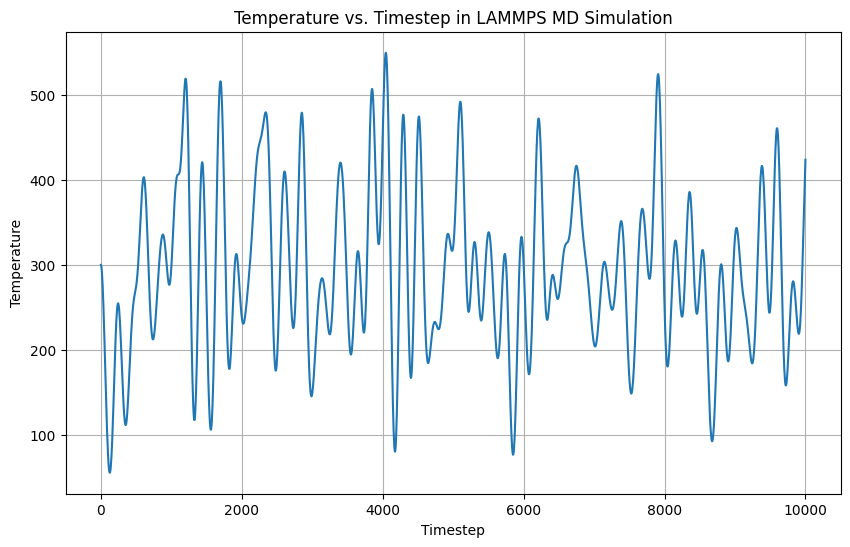

In [47]:
import re
import matplotlib.pyplot as plt
import pandas as pd

def parse_lammps_thermo_output(lammps_stdout):
    steps = []
    temps = []
    data_started = False
    for line in lammps_stdout.splitlines():
        if "Loop time" in line:
            data_started = False # Stop parsing once loop time is encountered
        if data_started:
            parts = line.strip().split()
            if len(parts) >= 2: # Ensure there are enough columns for Step and Temp
                try:
                    step = int(parts[0])
                    temp = float(parts[1])
                    steps.append(step)
                    temps.append(temp)
                except ValueError:
                    continue # Skip lines that don't parse as numbers
        if "Step          Temp" in line:
            data_started = True
    return pd.DataFrame({'Step': steps, 'Temp': temps})

# Assuming long_result is available from the previous cell execution
if 'long_result' in locals() and long_result.stdout:
    df_thermo = parse_lammps_thermo_output(long_result.stdout)

    if not df_thermo.empty:
        fig, ax = plt.subplots(figsize=(10, 6))
        ax.plot(df_thermo['Step'], df_thermo['Temp'])
        ax.set_xlabel('Timestep')
        ax.set_ylabel('Temperature')
        ax.set_title('Temperature vs. Timestep in LAMMPS MD Simulation')
        ax.grid(True)
        plt.show()
    else:
        print("No thermodynamic data found in LAMMPS stdout to plot.")
else:
    print("LAMMPS long_result not found or stdout is empty.")

In [48]:
print(f"Content of LAMMPS log file: {long_log}")
if long_log.exists():
    print(long_log.read_text())
else:
    print(f"Error: Log file not found at {long_log}")

Content of LAMMPS log file: /content/FitSNAP/fitsnap_tutorial_work/md_long_logs/Ta_md_demo_pot_10000__fit1a9b0507__lammps-611ca3b7f8__nvt.log
LAMMPS (22 Jul 2025 - Update 4)
OMP_NUM_THREADS environment is not set. Defaulting to 1 thread.
  using 1 OpenMP thread(s) per MPI task
variable nrep equal 2
units metal
boundary p p p
lattice bcc 3.316
Lattice spacing in x,y,z = 3.316 3.316 3.316
region box block 0 2 0 2 0 2
create_box 1 box
Created orthogonal box = (0 0 0) to (6.632 6.632 6.632)
  1 by 1 by 1 MPI processor grid
create_atoms 1 box
Created 16 atoms
  using lattice units in orthogonal box = (0 0 0) to (6.632 6.632 6.632)
  create_atoms CPU = 0.000 seconds
mass 1 180.88
include /content/FitSNAP/fitsnap_tutorial_work/Ta_md_demo_pot.mod
# This file was generated by FitSNAP.
# Hash: a568530ed474ebd003f328cfad5d1de9

pair_style hybrid/overlay zbl 4.0 4.8 pace product
ACE version: 2023.11.25
Product evaluator is used
pair_coeff * * zbl 73 73
pair_coeff * * pace /content/FitSNAP/fitsnap_

### If the optional 10,000-step check becomes unstable, reduce alpha in R...
- If the optional 10,000-step check becomes unstable, reduce `alpha` in RIDGE and keep
  the same thermostat settings when you restart.
- After this run, move from single-element to the multi-element InP workflow with `pair_coeff * * InP_pot.yace In P`.


### Useful utilities to explore next (no neural networks)

For further undergrad investigation, try these scripts from `examples/library`:

- `basic_examples/example1.py` (compact fit/error loop),
- `loop_over_fits/example2.py` (reuse descriptors for repeated fits),
- `transpose_trick/example.py` (memory-efficient descriptor handling),
- `genetic_algorithm/script_optimize.py` (group-weight optimization workflow),
- `genetic_algorithm/README.md` (important notes on reproducibility and GA objective).
